In [ ]:
try:
    from google.colab import files
    print("Upload: decoder.h5, forward_model.h5, preprocessor_forward.pkl, y_scaler.pkl, Dataset 6655.csv")
    _ = files.upload()
except Exception:
    pass

Upload: decoder.h5, forward_model.h5, preprocessor_forward.pkl, y_scaler.pkl, Dataset 6655.csv


Saving decoder.h5 to decoder.h5
Saving forward_model.h5 to forward_model.h5
Saving preprocessor_forward.pkl to preprocessor_forward.pkl
Saving y_scaler.pkl to y_scaler.pkl


In [ ]:
# Install & imports

try:
    import optuna  # already installed
except Exception:
    !pip -q install optuna
    import optuna

import os, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.dpi'] = 110

In [ ]:
# Paths & constants

DECODER_PATH = "decoder.h5"
FORWARD_PATH = "forward_model.h5"
PREPROC_PATH = "preprocessor_forward.pkl"
YSCL_PATH    = "y_scaler.pkl"
CSV_PATH     = "Dataset 6655.csv"

LATTICE_LABELS  = ["Hexagonal", "Square"]
MATERIAL_LABELS = ["Au", "Ag", "a-SiOx:H"]

# Fixed categories (Row-0): Square / Au
LAT_ROW0, MAT_ROW0 = 1, 0
# Row-0 geometry (your selected target)
T0, R0, P0 = 150.0, 110.0, 490.0

# Hierarchical search settings (keep as-is today)
COARSE_P_WINDOW = 80.0
TOP_P_KEEP      = 8
STAGE_B_TRIALS  = 120
STAGE_C_TRIALS  = 180

# Micro-sweep window on dataset grid
MICRO_WIN_T, MICRO_WIN_R, MICRO_WIN_P = 20, 10, 15

# Latent box (tight)
Z_LOW, Z_HIGH = -0.8, 0.8

In [ ]:
# Load models & preprocessors

decoder = keras.models.load_model(DECODER_PATH, compile=False)
forward_model = keras.models.load_model(FORWARD_PATH, compile=False)
with open(PREPROC_PATH, "rb") as f: preprocessor_forward = pickle.load(f)
with open(YSCL_PATH, "rb") as f:    y_scaler = pickle.load(f)

LATENT_DIM = int(decoder.inputs[0].shape[-1])
print(f"Loaded models. Latent dim = {LATENT_DIM}")

Loaded models. Latent dim = 16


In [ ]:
# Dataset & grids

param_cols = ['Lattice','Material','Thickness','Radius','Periodicity']
spec_cols  = [f'λ_{i}' for i in range(200)]
df = pd.read_csv(CSV_PATH, header=None, names=param_cols+spec_cols)

T_vals = np.sort(df['Thickness'].unique())
R_vals = np.sort(df['Radius'].unique())
P_vals = np.sort(df['Periodicity'].unique())

def snap_to_grid(x, grid):
    return float(grid[np.abs(grid - x).argmin()])


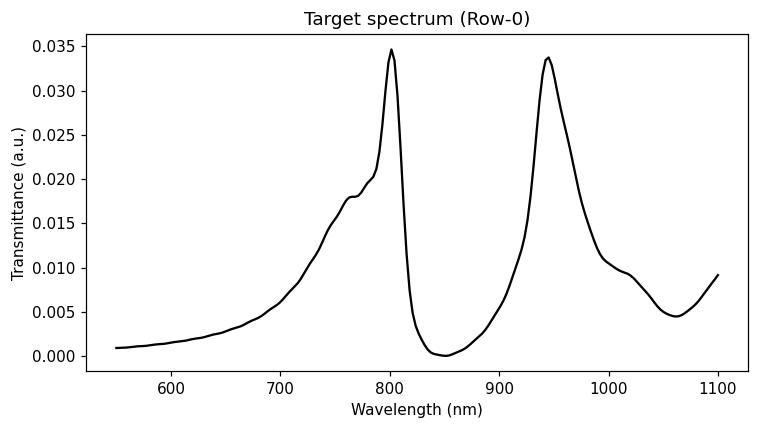

Sanity — Row-0 forward: MSE= 3.946490258108986e-05  MAE= 0.004310883957105005


In [ ]:
# Target spectrum (Row-0) & normalization

row0 = df[(df['Lattice']==LAT_ROW0)&(df['Material']==MAT_ROW0)&
          (df['Thickness']==T0)&(df['Radius']==R0)&(df['Periodicity']==P0)].head(1)
assert len(row0)==1, "Row-0 geometry not found in CSV. Check LAT_ROW0/MAT_ROW0/T0/R0/P0."

target_spectrum = row0[spec_cols].values.reshape(-1).astype(np.float32)
target_norm = y_scaler.transform(pd.DataFrame([target_spectrum], columns=spec_cols)).ravel()

wl = np.linspace(550, 1100, 200)
plt.figure(figsize=(7,4))
plt.plot(wl, target_spectrum, color="black")
plt.title("Target spectrum (Row-0)"); plt.xlabel("Wavelength (nm)"); plt.ylabel("Transmittance (a.u.)")
plt.tight_layout(); plt.show()

# Forward sanity on Row-0
Xp0 = preprocessor_forward.transform(row0[param_cols])
y0_pred_norm = np.clip(forward_model.predict(Xp0, verbose=0), 0.0, 1.0)
y0_pred = y_scaler.inverse_transform(y0_pred_norm)
print("Sanity — Row-0 forward: MSE=",
      float(np.mean((y0_pred - row0[spec_cols].values)**2)),
      " MAE=", float(np.mean(np.abs(y0_pred - row0[spec_cols].values))))

In [ ]:
# Fixed feature-weighted loss (keep as-is)
# Emphasize ~800 nm & ~940 nm peaks and ~870 nm dip

def gauss(x, mu, sigma):
    return np.exp(-0.5*((x-mu)/sigma)**2)

MU_P1, SIG_P1 = 800.0, 20.0  # left peak
MU_DIP, SIG_D = 870.0, 18.0  # central dip
MU_P2, SIG_P2 = 940.0, 22.0  # right peak

W_FEAT = 1.0 + 2.0*gauss(wl, MU_P1, SIG_P1) + 3.0*gauss(wl, MU_DIP, SIG_D) + 2.0*gauss(wl, MU_P2, SIG_P2)
EPS = 1e-8

def feature_weighted_loss(y_true, y_pred):
    """
    y_* are (N,200) in normalized space.
    """
    w = W_FEAT.reshape(1, -1)
    mse = np.mean(w * (y_pred - y_true)**2, axis=1)
    dot = np.sum(y_true * y_pred, axis=1)
    den = (np.linalg.norm(y_true, axis=1)*np.linalg.norm(y_pred, axis=1) + EPS)
    cos_loss = 1.0 - (dot/den)
    base = np.mean(np.abs(y_pred - y_true.mean(axis=1, keepdims=True)), axis=1)
    return mse + 0.2*cos_loss + 0.3*base

def forward_from_geom(lat_idx, mat_idx, T, R, P):
    df_in = pd.DataFrame({"Lattice":[lat_idx], "Material":[mat_idx],
                          "Thickness":[T], "Radius":[R], "Periodicity":[P]})
    Xp = preprocessor_forward.transform(df_in)
    y_pred_norm = forward_model.predict(Xp, verbose=0)
    return np.clip(y_pred_norm, 0.0, 1.0)


In [ ]:
# Hierarchical search: Coarse P → BO(T,R|P) → Fine TRP
# Coarse scan on P around P0

P_candidates = P_vals[(P_vals >= P0-COARSE_P_WINDOW) & (P_vals <= P0+COARSE_P_WINDOW)]
if len(P_candidates)==0: P_candidates = P_vals

scores_A = []
for P_try in P_candidates:
    y_pred_norm = forward_from_geom(LAT_ROW0, MAT_ROW0, T0, R0, float(P_try))
    loss = feature_weighted_loss(target_norm.reshape(1,-1), y_pred_norm)[0]
    scores_A.append((loss, float(P_try)))
scores_A.sort(key=lambda x: x[0])
topP = [p for _, p in scores_A[:TOP_P_KEEP]]
print("Top P from coarse scan:", topP[:5], ("..." if len(topP)>5 else ""))

# Stage B: Optuna over T/R for each top P (categories fixed)
DELTA_T, DELTA_R = 70.0, 45.0  # small geometry deltas around Row-0

best_TR_for_P = {}

def objective_TR(trial, P_fixed):
    # Optional latent (kept tight); decoder in loop for stability
    z = np.array([trial.suggest_float(f"z{i}", Z_LOW, Z_HIGH) for i in range(LATENT_DIM)],
                 dtype=np.float32).reshape(1,-1)
    _ = decoder.predict([z, target_norm.reshape(1,-1)], verbose=0)  # not used downstream

    dT = trial.suggest_float("dT", -DELTA_T, DELTA_T)
    dR = trial.suggest_float("dR", -DELTA_R, DELTA_R)
    T = snap_to_grid(np.clip(T0 + dT, T_vals.min(), T_vals.max()), T_vals)
    R = snap_to_grid(np.clip(R0 + dR, R_vals.min(), R_vals.max()), R_vals)

    y_pred_norm = forward_from_geom(LAT_ROW0, MAT_ROW0, T, R, P_fixed)
    loss = feature_weighted_loss(target_norm.reshape(1,-1), y_pred_norm)[0]
    loss += 0.02*((dT/DELTA_T)**2 + (dR/DELTA_R)**2)  # mild regularization
    return float(loss), T, R

for P_fixed in topP:
    sampler = optuna.samplers.TPESampler(seed=int(P_fixed))
    study = optuna.create_study(direction="minimize", sampler=sampler)
    def wrapped(trial):
        val, T, R = objective_TR(trial, P_fixed)
        if val < study.user_attrs.get("best_val", 1e9):
            study.set_user_attr("best_val", val)
            study.set_user_attr("best_T", float(T))
            study.set_user_attr("best_R", float(R))
        return val
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        study.optimize(wrapped, n_trials=STAGE_B_TRIALS, show_progress_bar=False)
    best_TR_for_P[P_fixed] = (study.user_attrs["best_val"],
                              study.user_attrs["best_T"],
                              study.user_attrs["best_R"])

# Pick Stage-B winner
P_best, (loss_B, T_best, R_best) = sorted(best_TR_for_P.items(), key=lambda kv: kv[1][0])[0]
print(f"Stage B best: P={P_best}, T={T_best}, R={R_best}, loss={loss_B:.4g}")

# Stage C: fine TRP around Stage-B winner
Z_LOW_FINE, Z_HIGH_FINE = -0.6, 0.6
DT, DR, DP = 30.0, 20.0, 25.0

def objective_fine(trial):
    z = np.array([trial.suggest_float(f"z{i}", Z_LOW_FINE, Z_HIGH_FINE) for i in range(LATENT_DIM)],
                 dtype=np.float32).reshape(1,-1)
    _ = decoder.predict([z, target_norm.reshape(1,-1)], verbose=0)

    T = snap_to_grid(np.clip(T_best + trial.suggest_float("dT", -DT, DT), T_vals.min(), T_vals.max()), T_vals)
    R = snap_to_grid(np.clip(R_best + trial.suggest_float("dR", -DR, DR), R_vals.min(), R_vals.max()), R_vals)
    P = snap_to_grid(np.clip(P_best + trial.suggest_float("dP", -DP, DP), P_vals.min(), P_vals.max()), P_vals)

    y_pred_norm = forward_from_geom(LAT_ROW0, MAT_ROW0, T, R, P)
    loss = feature_weighted_loss(target_norm.reshape(1,-1), y_pred_norm)[0]
    return float(loss), T, R, P

samplerC = optuna.samplers.TPESampler(seed=202)
studyC = optuna.create_study(direction="minimize", sampler=samplerC)
def wrappedC(trial):
    val, T, R, P = objective_fine(trial)
    if val < studyC.user_attrs.get("best_val", 1e9):
        studyC.set_user_attr("best_val", val)
        studyC.set_user_attr("best_T", float(T))
        studyC.set_user_attr("best_R", float(R))
        studyC.set_user_attr("best_P", float(P))
    return val

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    studyC.optimize(wrappedC, n_trials=STAGE_C_TRIALS, show_progress_bar=False)

T_final = studyC.user_attrs["best_T"]
R_final = studyC.user_attrs["best_R"]
P_final = studyC.user_attrs["best_P"]
print(f"Stage C best: T={T_final}, R={R_final}, P={P_final}, loss={studyC.user_attrs['best_val']:.4g}")


[I 2025-08-23 16:42:36,606] A new study created in memory with name: no-name-2824e13a-c382-4356-8c0f-c79a7881da1b


Top P from coarse scan: [495.0, 490.0, 500.0, 485.0, 505.0] ...


[I 2025-08-23 16:42:36,832] Trial 0 finished with value: 0.011509840539327333 and parameters: {'z0': -0.33909888124492565, 'z1': 0.7703981075089543, 'z2': 0.39888415753903717, 'z3': 0.029979457965032985, 'z4': 0.08186501854467809, 'z5': 0.24693561353920468, 'z6': 0.7377331825178846, 'z7': 0.011390510013839283, 'z8': 0.5803346450131035, 'z9': 0.4074866748764081, 'z10': 0.2716571525119602, 'z11': 0.3947746289045173, 'z12': 0.16932057482796892, 'z13': -0.4009555780152873, 'z14': -0.5617885884015981, 'z15': 0.3300076778936183, 'dT': 8.41460146521527, 'dR': -1.8660992936043215}. Best is trial 0 with value: 0.011509840539327333.
[I 2025-08-23 16:42:37,013] Trial 1 finished with value: 0.028381541493292847 and parameters: {'z0': -0.3857230383771823, 'z1': -0.4011724615524326, 'z2': 0.25648456563110944, 'z3': 0.6160455346304661, 'z4': 0.31734851451697166, 'z5': -0.31278322644113765, 'z6': -0.011355627335227547, 'z7': -0.38438769237922304, 'z8': 0.035205196548215745, 'z9': -0.5281606619126138, 

Stage B best: P=495.0, T=150.0, R=115.0, loss=0.01038


[I 2025-08-23 16:47:02,992] Trial 0 finished with value: 0.03463009244809668 and parameters: {'z0': -0.330952584012448, 'z1': -0.28313482680553836, 'z2': 0.5728333833754587, 'z3': 0.5915248399597698, 'z4': 0.5939905223206133, 'z5': 0.08577064556512382, 'z6': 0.11952839902259749, 'z7': -0.46280990490445334, 'z8': 0.37202847815844, 'z9': -0.3217630738579571, 'z10': 0.589252256581556, 'z11': 0.06315854763344364, 'z12': -0.07347804937187652, 'z13': -0.4956081679162968, 'z14': -0.07396458586813437, 'z15': 0.4474130941327218, 'dT': -5.3266530230127245, 'dR': 9.730609801952326, 'dP': -14.082735135401375}. Best is trial 0 with value: 0.03463009244809668.
[I 2025-08-23 16:47:03,189] Trial 1 finished with value: 0.01603543237205441 and parameters: {'z0': 0.4453548758276288, 'z1': 0.06314032614964349, 'z2': -0.36758040211637927, 'z3': -0.08185441633363966, 'z4': 0.3052896992800648, 'z5': -0.04245478829196703, 'z6': -0.26014420039707853, 'z7': 0.4586501081882547, 'z8': -0.18745581127381022, 'z9': 

Stage C best: T=150.0, R=120.0, P=500.0, loss=0.01021


In [ ]:
# Micro-fine sweep (tiny brute force around winner)

Ts = [t for t in T_vals if T_final - MICRO_WIN_T <= t <= T_final + MICRO_WIN_T]
Rs = [r for r in R_vals if R_final - MICRO_WIN_R <= r <= R_final + MICRO_WIN_R]
Ps = [p for p in P_vals if P_final - MICRO_WIN_P <= p <= P_final + MICRO_WIN_P]

best_local = (1e9, None, None, None, None)
for T in Ts:
    for R in Rs:
        for P in Ps:
            y_pred_norm = forward_from_geom(LAT_ROW0, MAT_ROW0, T, R, P)
            loss = feature_weighted_loss(target_norm.reshape(1,-1), y_pred_norm)[0]
            if loss < best_local[0]:
                best_local = (loss, float(T), float(R), float(P), y_pred_norm)

loss_loc, T_loc, R_loc, P_loc, y_loc = best_local
y_loc_inv = y_scaler.inverse_transform(y_loc)
mse_loc = float(np.mean((y_loc_inv - target_spectrum.reshape(1,-1))**2))
mae_loc = float(np.mean(np.abs(y_loc_inv - target_spectrum.reshape(1,-1))))
print("Micro-sweep best:", {"T":T_loc, "R":R_loc, "P":P_loc}, "MSE:", mse_loc, "MAE:", mae_loc)


Micro-sweep best: {'T': 150.0, 'R': 120.0, 'P': 500.0} MSE: 2.2561032892554067e-05 MAE: 0.003197710495442152


In [ ]:
# Material toggle (single check at final T/R/P)

best_mat = (1e9, None, None)
for mat in [0,1,2]:
    y_pred_norm = forward_from_geom(LAT_ROW0, mat, T_loc, R_loc, P_loc)
    y_inv = y_scaler.inverse_transform(y_pred_norm)
    mse = float(np.mean((y_inv - target_spectrum.reshape(1,-1))**2))
    mae = float(np.mean(np.abs(y_inv - target_spectrum.reshape(1,-1))))
    print(f"Material {MATERIAL_LABELS[mat]} -> MSE={mse:.6g}, MAE={mae:.6g}")
    if mse < best_mat[0]: best_mat = (mse, mae, mat)

mse_best_mat, mae_best_mat, mat_idx_final = best_mat
print("Chosen material:", MATERIAL_LABELS[mat_idx_final])

# Final spectrum with chosen material
y_best_norm = forward_from_geom(LAT_ROW0, mat_idx_final, T_loc, R_loc, P_loc)
y_best = y_scaler.inverse_transform(y_best_norm)

Material Au -> MSE=2.2561e-05, MAE=0.00319771
Material Ag -> MSE=9.53032e-05, MAE=0.00676778
Material a-SiOx:H -> MSE=0.41322, MAE=0.622601
Chosen material: Au



FINAL — MSE=2.2561e-05, MAE=0.00319771
{'Lattice': 'Square', 'Material': 'Au', 'Thickness(nm)': 150.0, 'Radius(nm)': 120.0, 'Periodicity(nm)': 500.0}


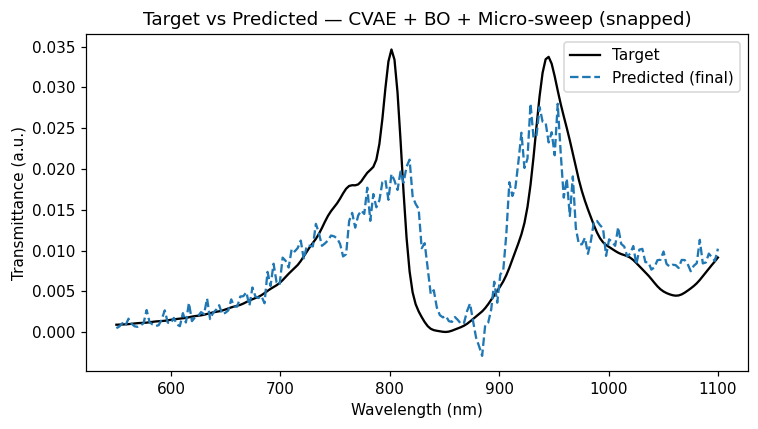

Saved: best_geometry.csv, target_spectrum.csv, predicted_spectrum.csv, cvae_bo_best_fit.png


In [ ]:
# Report, save, plot

final_mse = float(np.mean((y_best - target_spectrum.reshape(1,-1))**2))
final_mae = float(np.mean(np.abs(y_best - target_spectrum.reshape(1,-1))))
print(f"\nFINAL — MSE={final_mse:.6g}, MAE={final_mae:.6g}")
print({"Lattice": LATTICE_LABELS[LAT_ROW0],
       "Material": MATERIAL_LABELS[mat_idx_final],
       "Thickness(nm)": float(T_loc), "Radius(nm)": float(R_loc), "Periodicity(nm)": float(P_loc)})

# save artifacts
np.savetxt("best_geometry.csv",
           np.array([[LAT_ROW0, mat_idx_final, T_loc, R_loc, P_loc]]),
           delimiter=",",
           header="Lattice,Material,Thickness_nm,Radius_nm,Periodicity_nm", comments="")
np.savetxt("target_spectrum.csv", target_spectrum, delimiter=",")
np.savetxt("predicted_spectrum.csv", y_best.reshape(-1), delimiter=",")

plt.figure(figsize=(7,4))
plt.plot(wl, target_spectrum, label="Target", color="black")
plt.plot(wl, y_best.reshape(-1), label="Predicted (final)", linestyle="--")
plt.xlabel("Wavelength (nm)"); plt.ylabel("Transmittance (a.u.)")
plt.title("Target vs Predicted — CVAE + BO + Micro-sweep (snapped)")
plt.legend(); plt.tight_layout(); plt.savefig("cvae_bo_best_fit.png", dpi=300)
plt.show()

print("Saved: best_geometry.csv, target_spectrum.csv, predicted_spectrum.csv, cvae_bo_best_fit.png")